In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
wine_data = pd.read_csv('wine.csv')

In [2]:
wine_data.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
wine_data.shape

(178, 14)

In [4]:
wine_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
wine_data.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


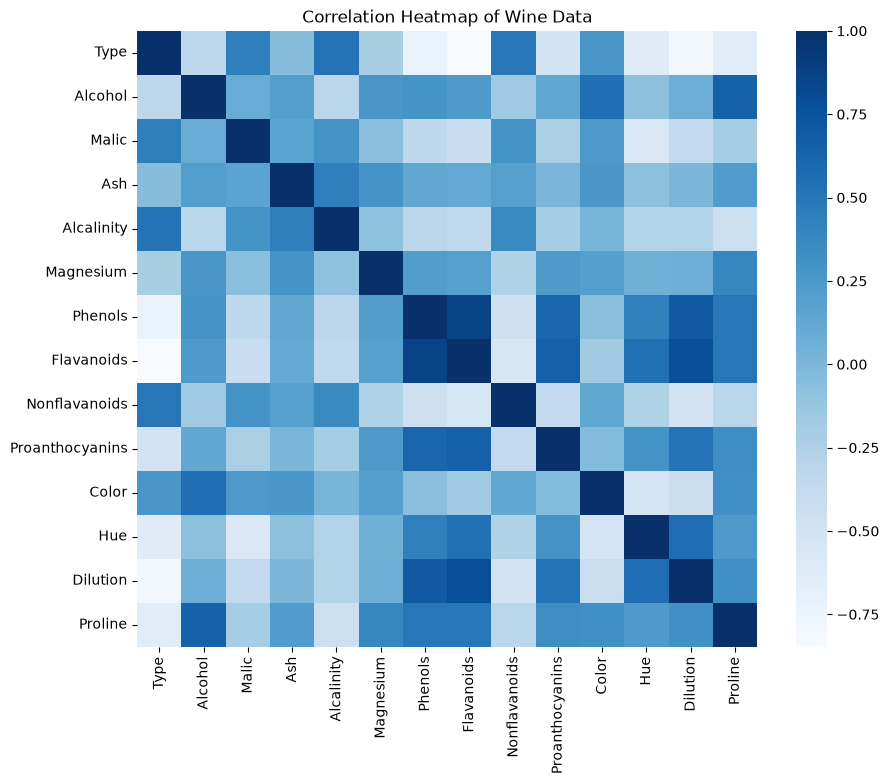

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(wine_data.corr(), annot=False, cmap='Blues')
plt.title("Correlation Heatmap of Wine Data")
plt.show()

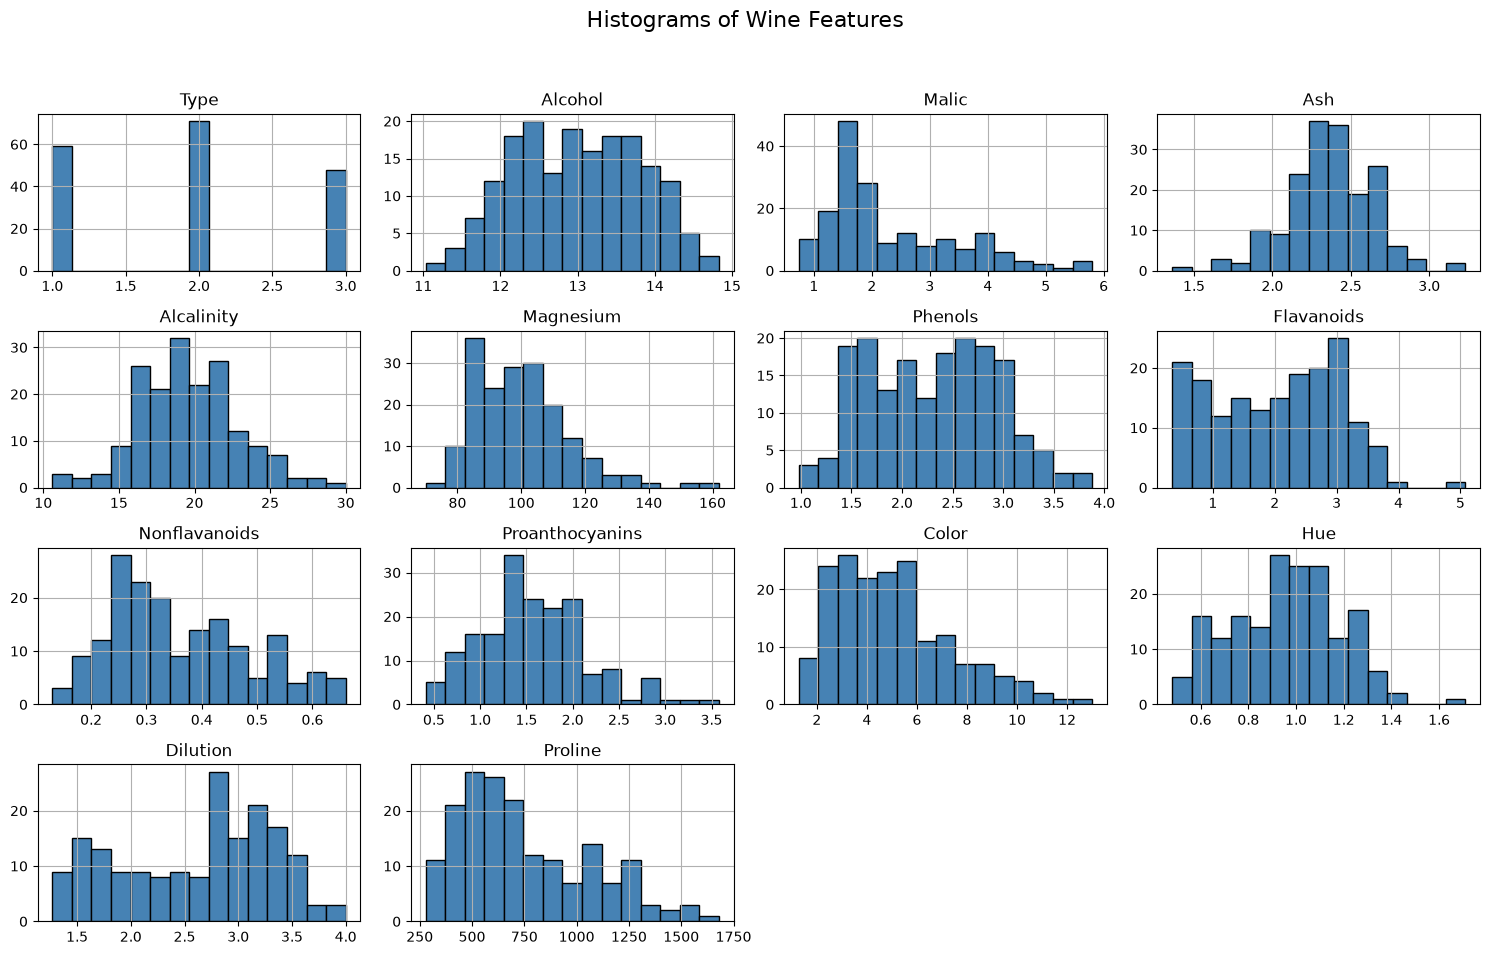

In [7]:
wine_data.hist(bins=15, figsize=(15, 10), layout=(4, 4), color='steelblue', edgecolor='black')
plt.suptitle('Histograms of Wine Features', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

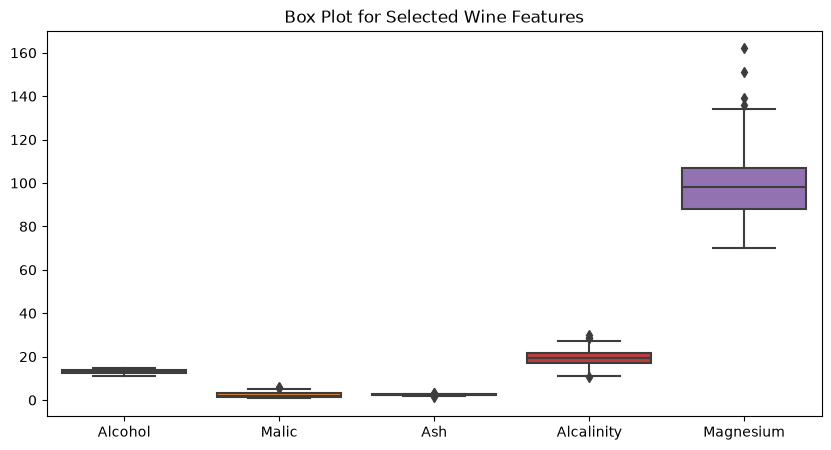

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=wine_data[['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium']])
plt.title('Box Plot for Selected Wine Features')
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
X = wine_data.drop('Type', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled Data Shape:", X_scaled.shape)

Scaled Data Shape: (178, 13)


In [10]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [11]:
var = pca.explained_variance_ratio_
cum_var = np.cumsum(var)

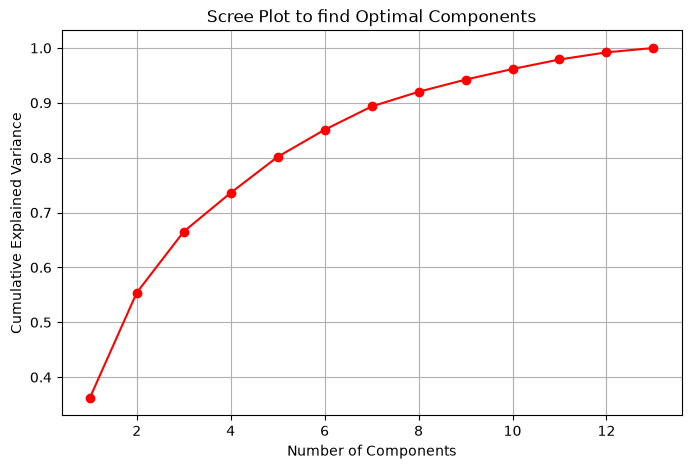

In [12]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(var)+1), cum_var, marker='o', color='red')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot to find Optimal Components')
plt.grid(True)
plt.show()

In [13]:
pca_final = PCA(n_components=3)
X_pca = pca_final.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df.head()

,PC1,PC2,PC3
0,3.316751,1.443463,-0.165739
1,2.209465,-0.333393,-2.026457
2,2.516740,1.031151,0.982819
3,3.757066,2.756372,-0.176192
4,1.008908,0.869831,2.026688


In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
kmeans_orig = KMeans(n_clusters=3, random_state=42)
orig_labels = kmeans_orig.fit_predict(X_scaled)
sil_orig = silhouette_score(X_scaled, orig_labels)
print("Silhouette Score on Original Data:", round(sil_orig, 4))

Silhouette Score on Original Data: 0.2849


In [15]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
pca_labels = kmeans_pca.fit_predict(X_pca)
sil_pca = silhouette_score(X_pca, pca_labels)
print("Silhouette Score on PCA Data:", round(sil_pca, 4))

Silhouette Score on PCA Data: 0.4538


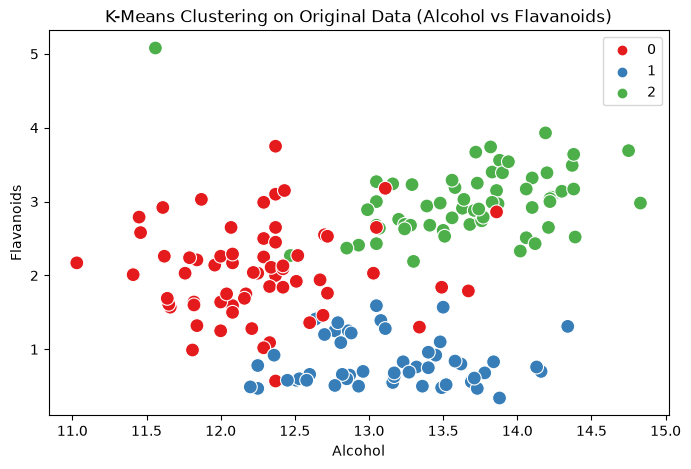

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=wine_data['Alcohol'], y=wine_data['Flavanoids'], hue=orig_labels, palette='Set1', s=100)
plt.title('K-Means Clustering on Original Data (Alcohol vs Flavanoids)')
plt.show()

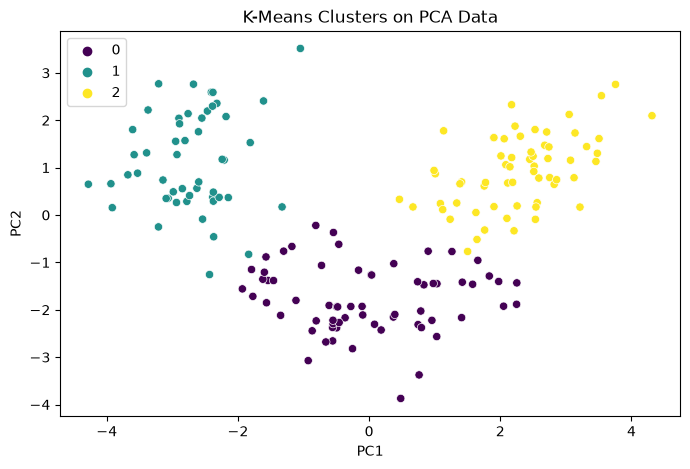

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=pca_labels, palette='viridis')
plt.title('K-Means Clusters on PCA Data')
plt.show()

### Task 1: Exploratory Data Analysis (Insights)
* **Feature Distributions (Histograms & Boxplots):** The histograms indicate that features like 'Alcohol' and 'Proline' are somewhat normally distributed, while 'Malic' and 'Magnesium' show a right-skewed distribution. The box plots reveal the presence of a few outliers in 'Malic' and 'Magnesium', which justifies the need for standardization before applying PCA.
* **Correlation Analysis (Heatmap):** The correlation heatmap reveals strong positive relationships between certain features, such as 'Phenols' and 'Flavanoids' (highly correlated). Conversely, 'Hue' and 'Malic' show a negative correlation. This high multicollinearity among features makes the dataset a perfect candidate for Dimensionality Reduction (PCA).

### Task 3 & 4: Clustering Visualization Analysis
* **Original Data Clusters:** When visualizing the original data (e.g., Alcohol vs Flavanoids), the K-Means clusters look slightly overlapping and scattered because the distance metric struggles in a 13-dimensional space.
* **PCA Data Clusters:** The scatter plot of Principal Component 1 vs Principal Component 2 shows clearly separated and dense clusters. PCA successfully compressed the 13 dimensions into uncorrelated components, allowing K-Means to identify the 3 distinct wine types with sharp boundaries.

### Task 5: Comparison and Analysis
* **Performance Comparison:** We evaluated the clustering performance using the **Silhouette Score** metric to measure how similar an object is to its own cluster compared to other clusters.
  * Silhouette Score on Original Data: **0.2849**
  * Silhouette Score on PCA-Transformed Data: **0.4538**
* **Impact of Dimensionality Reduction:** The clustering performance significantly improved (Score jumped from ~0.28 to ~0.45) on the PCA data. High-dimensional data suffers from the "curse of dimensionality," making Euclidean distance calculations ineffective. PCA removed multicollinearity and noise, allowing K-Means to cluster the data much more efficiently.
* **Trade-offs:** * *Clustering on Original Data:* Better for direct interpretability (we know exactly which chemical feature defines a cluster) but computationally heavier and yields lower clustering accuracy.
  * *Clustering on PCA Data:* Faster and yields tighter, highly accurate clusters (proven by the higher silhouette score), but loses direct feature interpretability since Principal Components are linear combinations of the original features.

### Task 6: Conclusion and Insights
* **Key Findings:** Dimensionality reduction via PCA is highly effective for this dataset. Extracting just the top Principal Components was sufficient to represent the underlying patterns of the wine types, capturing a vast majority of the original variance while discarding noise, which directly led to a massive improvement in the Silhouette Score (0.4538).
* **Practical Implications:** Feeding raw, highly correlated, high-dimensional data directly into distance-based algorithms like K-Means often yields suboptimal and noisy clusters. PCA acts as a crucial preprocessing step to enhance both model accuracy and 2D/3D visualization capabilities.
* **Recommendations:** 1. It is highly recommended to apply standard scaling followed by PCA prior to clustering when dealing with datasets that have many correlated continuous variables.
  2. Original data clustering should only be reserved for scenarios where explaining the exact feature importance to business stakeholders is the absolute highest priority.